# Chronos-2 Multivariate Forecast (v2)

Fresh implementation using Chronos-2 with all 4 OHLC columns as multivariate targets.

**Key improvements over v1:**
- Target: all 4 OHLC columns jointly (multivariate) instead of close only
- Positions: long AND short (signal-based, not long-only)
- Sizing: Kelly-inspired `predicted_return / CI_width`, clipped to `[-1, 1]`
- Signal extracted by filtering `target_name == "close"` from Chronos output

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from chronos import Chronos2Pipeline

print('Python:', sys.executable)
print('pandas:', pd.__version__)
print('numpy:', np.__version__)

/Users/iliasmc/projects/hrt-datathon/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: /Users/iliasmc/projects/hrt-datathon/.venv/bin/python
pandas: 2.3.3
numpy: 2.4.4


In [2]:
DATA_DIR = '../data'
OUT_DIR  = '.'

DEVICE           = 'mps'
MODEL_ID         = 'amazon/chronos-2'
PREDICTION_LEN   = 50
TARGETS          = ['open', 'high', 'low', 'close']
QUANTILE_LEVELS  = [0.1, 0.5, 0.9]
BATCH_SIZE_TRAIN = 100
BATCH_SIZE_TEST  = 256

START_DATE = pd.to_datetime('2000-01-01')

EPSILON      = 0.001
CI_FLOOR     = 1e-4
MAX_POSITION = 1.0

In [3]:
train_seen   = pd.read_parquet(f'{DATA_DIR}/bars_seen_train.parquet')
train_unseen = pd.read_parquet(f'{DATA_DIR}/bars_unseen_train.parquet')
public_seen  = pd.read_parquet(f'{DATA_DIR}/bars_seen_public_test.parquet')
private_seen = pd.read_parquet(f'{DATA_DIR}/bars_seen_private_test.parquet')

print(f'Train seen:    {train_seen.shape}   sessions {train_seen.session.min()}-{train_seen.session.max()}')
print(f'Train unseen:  {train_unseen.shape}   sessions {train_unseen.session.min()}-{train_unseen.session.max()}')
print(f'Public test:   {public_seen.shape}  sessions {public_seen.session.min()}-{public_seen.session.max()}')
print(f'Private test:  {private_seen.shape}  sessions {private_seen.session.min()}-{private_seen.session.max()}')
display(train_seen.head(3))

Train seen:    (50000, 6)   sessions 0-999
Train unseen:  (50000, 6)   sessions 0-999
Public test:   (500000, 6)  sessions 1000-10999
Private test:  (500000, 6)  sessions 11000-20999


,bar_ix,session,open,high,low,close
0,0,0,1.0,1.0029,0.9986,0.9999
1,0,1,1.0,1.0024,0.9980,1.0011
2,0,2,1.0,1.0005,0.9952,0.9957


In [4]:
def add_timestamps(df):
    df = df.copy()
    df['timestamp'] = START_DATE + pd.to_timedelta(df['bar_ix'], unit='D')
    return df

train_seen   = add_timestamps(train_seen)
public_seen  = add_timestamps(public_seen)
private_seen = add_timestamps(private_seen)

print(f'Timestamp range (train seen): {train_seen.timestamp.min()} to {train_seen.timestamp.max()}')

Timestamp range (train seen): 2000-01-01 00:00:00 to 2000-02-19 00:00:00


In [5]:
pipeline = Chronos2Pipeline.from_pretrained(MODEL_ID, device_map=DEVICE)
print(f'Model loaded on device: {DEVICE}')

Model loaded on device: mps


In [6]:
def run_chronos(seen_df, cross_learning, batch_size, desc=''):
    """
    Run Chronos-2 multivariate inference on seen OHLC data.

    Returns long-format DataFrame with columns:
      session, timestamp, target_name, predictions, 0.1, 0.5, 0.9
    where target_name is one of open/high/low/close.
    Total rows = n_sessions x 4 targets x PREDICTION_LEN steps.
    """
    print(f'[{desc}] Running on {seen_df.session.nunique()} sessions ...')
    pred_df = pipeline.predict_df(
        seen_df,
        future_df=None,
        id_column='session',
        timestamp_column='timestamp',
        target=TARGETS,
        prediction_length=PREDICTION_LEN,
        quantile_levels=QUANTILE_LEVELS,
        batch_size=batch_size,
        cross_learning=cross_learning,
    )
    print(f'[{desc}] Done. Output shape: {pred_df.shape}')
    return pred_df

In [7]:
def extract_close_signal(seen_df, pred_df):
    """
    Convert multivariate Chronos output into a signed position per session.

    1. Filter to target_name == 'close'
    2. Take the last forecast step per session (bar 99)
    3. predicted_return = pred_close_99 / close_49 - 1
    4. ci_width = (q90 - q10) / close_49
    5. signal = predicted_return / ci_width  (Kelly-inspired)
    6. Threshold by EPSILON; clip to [-MAX_POSITION, +MAX_POSITION]
    """
    close_pred = pred_df[pred_df['target_name'] == 'close'].copy()

    pred_99 = (
        close_pred
        .sort_values('timestamp')
        .groupby('session', sort=False)
        .last()
        .rename(columns={'predictions': 'pred_99', '0.1': 'q10', '0.9': 'q90'})
    )

    close_49 = seen_df.groupby('session')['close'].last().rename('close_49')

    df = close_49.to_frame().join(pred_99)

    df['predicted_return'] = df['pred_99'] / df['close_49'] - 1
    df['ci_width'] = (df['q90'] - df['q10']) / df['close_49'].clip(lower=CI_FLOOR)
    df['signal'] = df['predicted_return'] / df['ci_width'].clip(lower=CI_FLOOR)

    tradeable = df['predicted_return'].abs() > EPSILON
    df['target_position'] = (
        np.where(tradeable, df['signal'], 0.0)
        .clip(-MAX_POSITION, MAX_POSITION)
    )

    return (
        df[['target_position']]
        .reset_index()[['session', 'target_position']]
        .sort_values('session')
    )

## Training Set: Inference and Evaluation

In [8]:
pred_train = run_chronos(
    train_seen,
    cross_learning=True,
    batch_size=BATCH_SIZE_TRAIN,
    desc='TRAIN',
)
print(f'Unique target_names: {pred_train["target_name"].unique().tolist()}')
display(pred_train.head(8))

[TRAIN] Running on 1000 sessions ...
[TRAIN] Done. Output shape: (200000, 7)
Unique target_names: ['open', 'high', 'low', 'close']


,session,timestamp,target_name,predictions,0.1,0.5,0.9
0,0,2000-02-20,open,1.028790,1.025709,1.028790,1.031582
1,0,2000-02-21,open,1.028522,1.024321,1.028522,1.032437
2,0,2000-02-22,open,1.028486,1.023265,1.028486,1.033486
3,0,2000-02-23,open,1.028358,1.021789,1.028358,1.034605
4,0,2000-02-24,open,1.028199,1.020692,1.028199,1.035561
5,0,2000-02-25,open,1.028170,1.019581,1.028170,1.036222
6,0,2000-02-26,open,1.028370,1.019029,1.028370,1.037163
7,0,2000-02-27,open,1.028538,1.018332,1.028538,1.037985


In [9]:
submission_train = extract_close_signal(train_seen, pred_train)

n_long  = (submission_train['target_position'] > 0).sum()
n_short = (submission_train['target_position'] < 0).sum()
n_flat  = (submission_train['target_position'] == 0).sum()

print(f'Training sessions: {len(submission_train)}')
print(f'  Long:  {n_long}  ({n_long/len(submission_train):.1%})')
print(f'  Short: {n_short}  ({n_short/len(submission_train):.1%})')
print(f'  Flat:  {n_flat}  ({n_flat/len(submission_train):.1%})')
display(submission_train.describe())

Training sessions: 1000
  Long:  332  (33.2%)
  Short: 385  (38.5%)
  Flat:  283  (28.3%)


,session,target_position
count,1000.000000,1000.000000
mean,499.500000,-0.002263
std,288.819436,0.078254
min,0.000000,-0.336177
25%,249.750000,-0.044040
50%,499.500000,0.000000
75%,749.250000,0.038569
max,999.000000,0.400108


In [10]:
import sys
sys.path.insert(0, '..')
from backtester import backtest

results_train = backtest(submission_train)

  Sessions evaluated : 1000
  Sharpe ratio       : -0.7624
  Mean PnL           : -0.000076
  Std  PnL           : 0.001592
  Win rate           : 35.00%


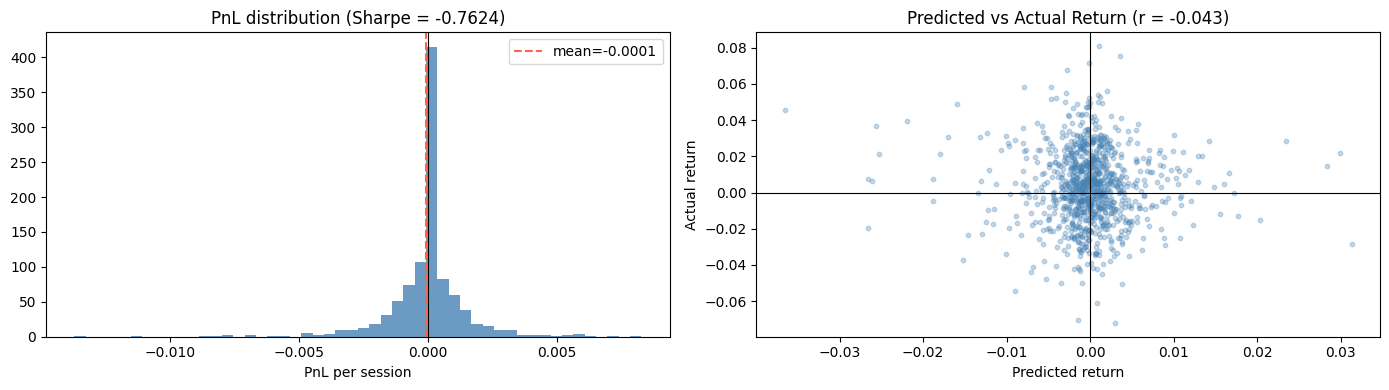

In [11]:
close_halfway = train_seen.groupby('session')['close'].last()
close_end     = train_unseen.groupby('session')['close'].last()
actual_ret    = (close_end / close_halfway - 1)

close_pred_99 = (
    pred_train[pred_train['target_name'] == 'close']
    .sort_values('timestamp')
    .groupby('session')
    .last()['predictions']
)
pred_ret = close_pred_99 / close_halfway - 1

scatter_df = pd.concat([pred_ret.rename('predicted'), actual_ret.rename('actual')], axis=1).dropna()
corr = scatter_df.corr().loc['predicted', 'actual']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pnl = results_train['pnl']
axes[0].hist(pnl, bins=50, color='steelblue', alpha=0.8, edgecolor='none')
axes[0].axvline(pnl.mean(), color='tomato', linestyle='--', label=f'mean={pnl.mean():+.4f}')
axes[0].axvline(0, color='k', lw=0.8)
axes[0].set_title(f'PnL distribution (Sharpe = {results_train.attrs["sharpe"]:.4f})')
axes[0].set_xlabel('PnL per session')
axes[0].legend()

axes[1].scatter(scatter_df['predicted'], scatter_df['actual'], alpha=0.3, s=10, color='steelblue')
axes[1].axhline(0, color='k', lw=0.8)
axes[1].axvline(0, color='k', lw=0.8)
axes[1].set_title(f'Predicted vs Actual Return (r = {corr:.3f})')
axes[1].set_xlabel('Predicted return')
axes[1].set_ylabel('Actual return')

plt.tight_layout()
plt.show()

## Test Set: Inference and Submissions

In [12]:
pred_public = run_chronos(
    public_seen,
    cross_learning=False,
    batch_size=BATCH_SIZE_TEST,
    desc='PUBLIC',
)
submission_public = extract_close_signal(public_seen, pred_public)

n_long  = (submission_public['target_position'] > 0).sum()
n_short = (submission_public['target_position'] < 0).sum()
print(f'Public: {len(submission_public)} sessions - long={n_long}, short={n_short}, flat={len(submission_public)-n_long-n_short}')
display(submission_public.describe())

[PUBLIC] Running on 10000 sessions ...
[PUBLIC] Done. Output shape: (2000000, 7)
Public: 10000 sessions - long=3942, short=3941, flat=2117


,session,target_position
count,10000.00000,10000.000000
mean,5999.50000,-0.000164
std,2886.89568,0.164619
min,1000.00000,-1.000000
25%,3499.75000,-0.066385
50%,5999.50000,0.000000
75%,8499.25000,0.069059
max,10999.00000,1.000000


In [13]:
pred_private = run_chronos(
    private_seen,
    cross_learning=False,
    batch_size=BATCH_SIZE_TEST,
    desc='PRIVATE',
)
submission_private = extract_close_signal(private_seen, pred_private)

n_long  = (submission_private['target_position'] > 0).sum()
n_short = (submission_private['target_position'] < 0).sum()
print(f'Private: {len(submission_private)} sessions - long={n_long}, short={n_short}, flat={len(submission_private)-n_long-n_short}')
display(submission_private.describe())

[PRIVATE] Running on 10000 sessions ...
[PRIVATE] Done. Output shape: (2000000, 7)
Private: 10000 sessions - long=4009, short=3866, flat=2125


,session,target_position
count,10000.00000,10000.000000
mean,15999.50000,-0.002167
std,2886.89568,0.161773
min,11000.00000,-1.000000
25%,13499.75000,-0.065388
50%,15999.50000,0.000000
75%,18499.25000,0.066763
max,20999.00000,1.000000


In [14]:
submission_combined = pd.concat([submission_public, submission_private], ignore_index=True)

assert len(submission_combined) == 20000, f'Expected 20000, got {len(submission_combined)}'
assert submission_combined['session'].nunique() == 20000, 'Duplicate sessions detected'
assert submission_combined['session'].min() == 1000
assert submission_combined['session'].max() == 20999
assert (submission_combined['target_position'].abs() <= MAX_POSITION + 1e-9).all(), 'Position exceeds cap'

PUBLIC_CSV   = f'{OUT_DIR}/submission_chronos_v2_public.csv'
PRIVATE_CSV  = f'{OUT_DIR}/submission_chronos_v2_private.csv'
COMBINED_CSV = f'{OUT_DIR}/submission_chronos_v2_combined.csv'

submission_public.to_csv(PUBLIC_CSV, index=False)
submission_private.to_csv(PRIVATE_CSV, index=False)
submission_combined.to_csv(COMBINED_CSV, index=False)

print(f'Saved {PUBLIC_CSV}   ({len(submission_public)} rows)')
print(f'Saved {PRIVATE_CSV}  ({len(submission_private)} rows)')
print(f'Saved {COMBINED_CSV} ({len(submission_combined)} rows)')
display(submission_combined.head(5))
display(submission_combined.tail(5))

Saved ./submission_chronos_v2_public.csv   (10000 rows)
Saved ./submission_chronos_v2_private.csv  (10000 rows)
Saved ./submission_chronos_v2_combined.csv (20000 rows)


,session,target_position
0,1000,-0.070327
1,1001,-0.090755
2,1002,0.000000
3,1003,-0.377310
4,1004,0.000000


,session,target_position
19995,20995,0.363944
19996,20996,0.000000
19997,20997,0.224401
19998,20998,0.046331
19999,20999,0.108067


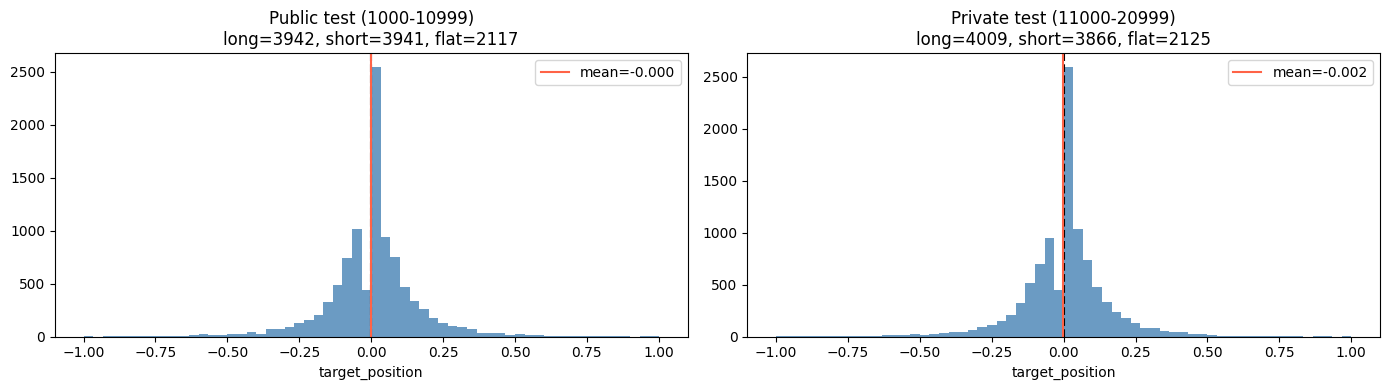


v2 summary:
  Training Sharpe:  -0.7624
  Mean PnL (train): -0.000076
  Win rate (train): 35.00%


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, df, label in [
    (axes[0], submission_public,  'Public test (1000-10999)'),
    (axes[1], submission_private, 'Private test (11000-20999)'),
]:
    pos = df['target_position']
    ax.hist(pos, bins=60, color='steelblue', alpha=0.8, edgecolor='none')
    ax.axvline(0, color='k', lw=1.5, linestyle='--')
    ax.axvline(pos.mean(), color='tomato', lw=1.5, label=f'mean={pos.mean():.3f}')
    n_long  = (pos > 0).sum()
    n_short = (pos < 0).sum()
    n_flat  = (pos == 0).sum()
    ax.set_title(f'{label}\nlong={n_long}, short={n_short}, flat={n_flat}')
    ax.set_xlabel('target_position')
    ax.legend()

plt.tight_layout()
plt.show()

print('\nv2 summary:')
print(f'  Training Sharpe:  {results_train.attrs["sharpe"]:+.4f}')
print(f'  Mean PnL (train): {results_train.attrs["mean_pnl"]:+.6f}')
print(f'  Win rate (train): {results_train.attrs["win_rate"]:.2%}')